## Step to install required packages to load dataset

In [ ]:
import sys
!{sys.executable} -m pip install datasets

## Loading data set from Hugging Face

In [ ]:
from datasets import load_dataset

dataset_name = 'mmenendezg/pneumonia_x_ray'
data = load_dataset(dataset_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/110M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/27.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4187 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1045 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

# Testing dataset and trail run of augumentation

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4187
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 1045
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500 at 0x7800284E73E0>, 'label': 0}


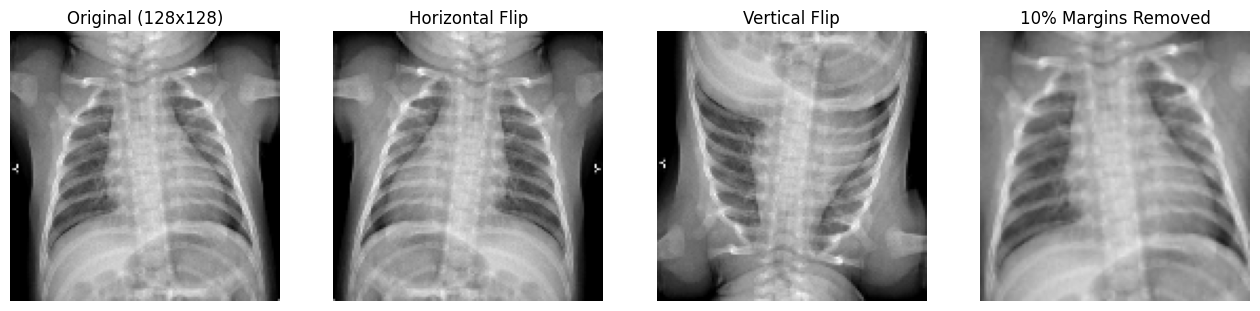

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Display the dataset structure and a sample
print(data)
print(data['train'][0])

if 'IMG_HEIGHT' not in globals() or 'IMG_WIDTH' not in globals():
    IMG_HEIGHT = 128
    IMG_WIDTH = 128

# Get a sample image from the training dataset
sample_image_pil = data['train'][0]['image']

# Convert PIL Image to TensorFlow Tensor and resize to standard input size
base_image_tensor = tf.convert_to_tensor(np.array(sample_image_pil), dtype=tf.float32)
base_image_tensor = tf.image.resize(base_image_tensor, (IMG_HEIGHT, IMG_WIDTH))

def flip_horizontal(image):
    """Flips the image horizontally (left-to-right)."""
    return tf.image.flip_left_right(image)

def flip_vertical(image):
    """Flips the image vertically (top-to-bottom)."""
    return tf.image.flip_up_down(image)

def crop_margins(image, percent):
    """Removes a percentage of pixels from all four margins (top, bottom, left, right) and resizes back."""
    height = tf.shape(image)[0]
    width = tf.shape(image)[1]

    crop_pixels_h = tf.cast(tf.cast(height, tf.float32) * percent, tf.int32)
    crop_pixels_w = tf.cast(tf.cast(width, tf.float32) * percent, tf.int32)

    target_height = height - (2 * crop_pixels_h)
    target_width = width - (2 * crop_pixels_w)

    cropped_image = tf.image.crop_to_bounding_box(
        image,
        offset_height=crop_pixels_h,
        offset_width=crop_pixels_w,
        target_height=target_height,
        target_width=target_width
    )
    cropped_image = tf.image.resize(cropped_image, (IMG_HEIGHT, IMG_WIDTH))
    return cropped_image

# Apply transformations
original_display = base_image_tensor / 255.0
horiz_flipped_display = flip_horizontal(base_image_tensor) / 255.0
vert_flipped_display = flip_vertical(base_image_tensor) / 255.0
cropped_display = crop_margins(base_image_tensor, 0.10) / 255.0

# Plotting the images
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_display)
plt.title("Original (128x128)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(horiz_flipped_display)
plt.title("Horizontal Flip")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(vert_flipped_display)
plt.title("Vertical Flip")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(cropped_display)
plt.title("10% Margins Removed")
plt.axis('off')

plt.show()



### 1.1 Integrate Augmentations into the Pipeline

Now, we define a function that applies the transformations (Horizontal Flip, Vertical Flip, and 10% Margin Removal) to the images in our dataset. We will then create new augmented datasets for training, validation, and testing.

In [ ]:
import tensorflow as tf

# Define necessary constants for the augmentation process
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 2

def augment_data(example):
    """
    Applies multiple transformations to a dataset example:
    1. Resize and Normalize
    2. Horizontal Flip
    3. Vertical Flip
    4. 10% Margin Removal
    """
    image = example['image']
    label = example['label']

    # Resize to standard input size
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    # 1. Flip Transformations
    image = tf.image.flip_left_right(image)
    image = tf.image.flip_up_down(image)

    # 2. Margin Removal (10%)
    percent = 0.10
    height = tf.shape(image)[0]
    width = tf.shape(image)[1]

    crop_h = tf.cast(tf.cast(height, tf.float32) * percent, tf.int32)
    crop_w = tf.cast(tf.cast(width, tf.float32) * percent, tf.int32)

    image = tf.image.crop_to_bounding_box(
        image,
        offset_height=crop_h,
        offset_width=crop_w,
        target_height=height - (2 * crop_h),
        target_width=width - (2 * crop_w)
    )

    # Resize back to target dimensions and normalize
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode label
    label = tf.one_hot(label, depth=NUM_CLASSES)

    return image, label

# Create augmented datasets without explicit batch_size at this step
train_dataset_aug = data['train'].to_tf_dataset(
    columns=['image', 'label'],
    shuffle=True
).map(augment_data)

val_dataset_aug = data['validation'].to_tf_dataset(
    columns=['image', 'label'],
    shuffle=False
).map(augment_data)

test_dataset_aug = data['test'].to_tf_dataset(
    columns=['image', 'label'],
    shuffle=False
).map(augment_data)

print("Augmented Datasets Created Successfully (Batching removed).")

Augmented Datasets Created Successfully (Batching removed).


Augmented Image batch shape: (32, 128, 128, 3)
Augmented Label batch shape: (32, 2)


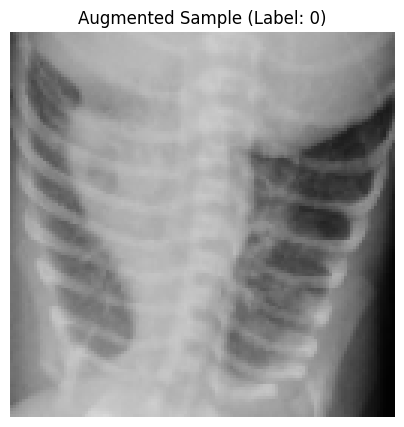


Augmentation verification complete. Datasets are ready for training.


In [ ]:
# Verify the output of the augmented dataset
# We add .batch() here since we removed it from the dataset creation
for images, labels in train_dataset_aug.batch(BATCH_SIZE).take(1):
    print(f"Augmented Image batch shape: {images.shape}")
    print(f"Augmented Label batch shape: {labels.shape}")

    plt.figure(figsize=(5, 5))
    # Display the first image in the batch
    plt.imshow(images[20])
    plt.title(f"Augmented Sample (Label: {tf.argmax(labels[0])})")
    plt.axis('off')
    plt.show()

print("\nAugmentation verification complete. Datasets are ready for training.")

# Augumentation of Pneumonia and Normal case (for couple of examples)

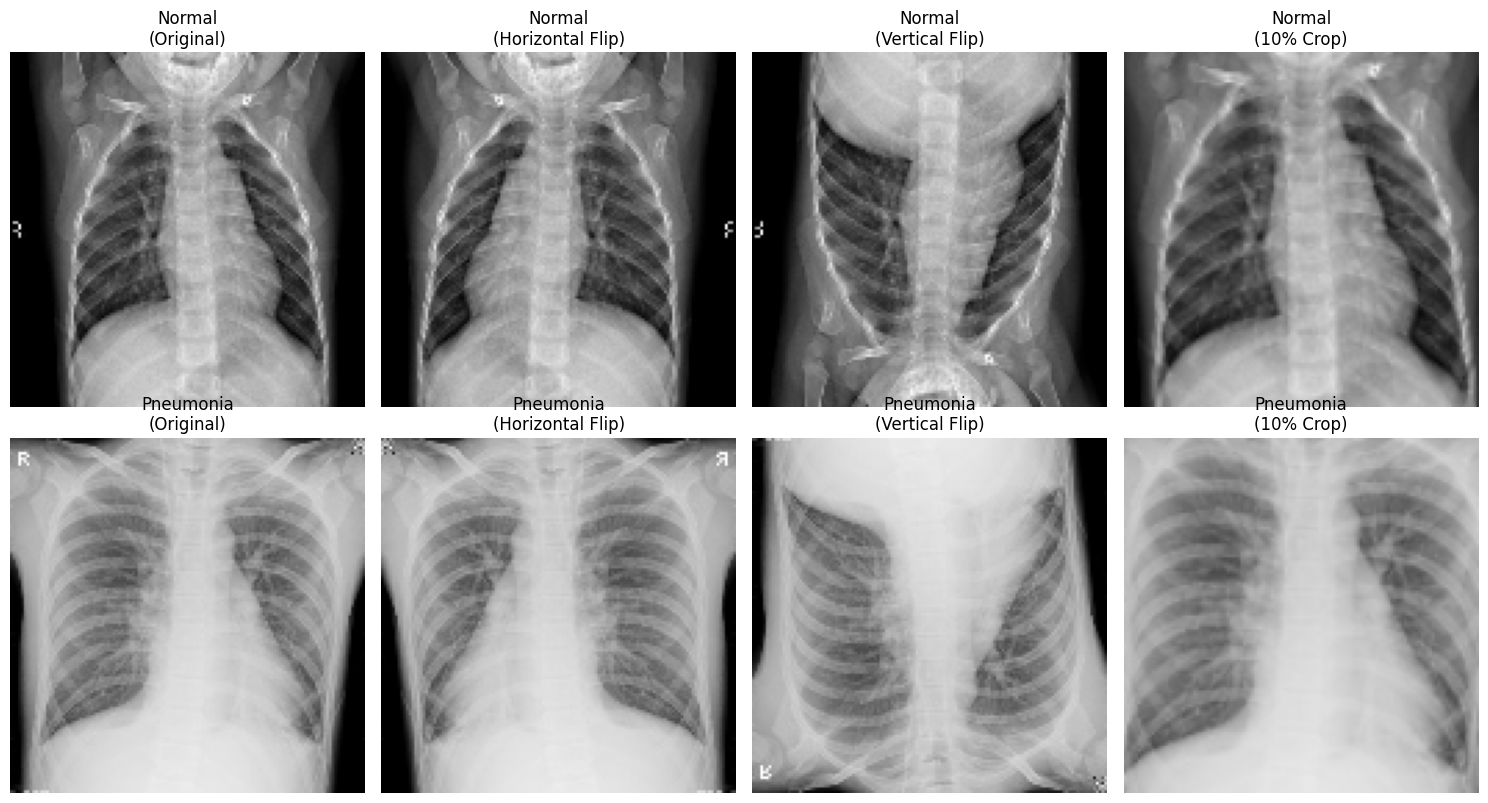

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np
import tensorflow as tf

def get_specific_augmented_image(sample, aug_type):
    # Convert and resize
    image = tf.convert_to_tensor(np.array(sample['image']), dtype=tf.float32)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    if aug_type == 'horiz':
        image = tf.image.flip_left_right(image)
    elif aug_type == 'vert':
        image = tf.image.flip_up_down(image)
    elif aug_type == 'crop':
        percent = 0.10
        h, w = tf.shape(image)[0], tf.shape(image)[1]
        ch = tf.cast(tf.cast(h, tf.float32) * percent, tf.int32)
        cw = tf.cast(tf.cast(w, tf.float32) * percent, tf.int32)
        image = tf.image.crop_to_bounding_box(image, ch, cw, h - 2*ch, w - 2*cw)
        image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))

    return image.numpy() / 255.0

# Sample specific cases for demonstration
normal_idx = random.choice([i for i, x in enumerate(data['train']) if x['label'] == 0])
pneumonia_idx = random.choice([i for i, x in enumerate(data['train']) if x['label'] == 1])

samples = [
    (data['train'][normal_idx], 'Normal'),
    (data['train'][pneumonia_idx], 'Pneumonia')
]

aug_types = [('Original', 'none'), ('Horizontal Flip', 'horiz'), ('Vertical Flip', 'vert'), ('10% Crop', 'crop')]

plt.figure(figsize=(15, 8))
plot_pos = 1

for sample_data, label_name in samples:
    for title_suffix, aug_key in aug_types:
        img = get_specific_augmented_image(sample_data, aug_key)
        plt.subplot(2, 4, plot_pos)
        plt.imshow(img)
        plt.title(f"{label_name}\n({title_suffix})")
        plt.axis('off')
        plot_pos += 1

plt.tight_layout()
plt.show()

### 1. Import Libraries and Define Preprocessing Functions

Importing TensorFlow and defining functions to preprocess the image data. This includes resizing, converting to arrays, and normalizing pixel values. Labels will be one-hot encoded.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# NEW: DenseNet needs its own preprocessing
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

# Define image size
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 2 # 0 for normal, 1 for pneumonia

def preprocess_image(example):
    # Convert PIL Image to TensorFlow Tensor
    image = example['image']
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0 # Normalize to [0, 1]
    return image

def preprocess_label(example):
    # One-hot encode labels
    label = example['label']
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return label

def preprocess_data(example):
    image = preprocess_image(example)
    label = preprocess_label(example)
    return image, label

# NEW: preprocessing only for DenseNet121 pretrained on ImageNet
def preprocess_image_densenet(example):
    image = example['image']
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32)  # keep 0-255 scale before DenseNet preprocessing
    image = densenet_preprocess_input(image)
    return image

def preprocess_data_densenet(example):
    image = preprocess_image_densenet(example)
    label = preprocess_label(example)
    return image, label

### 2. Convert Dataset and data augmentation



This step converts the Hugging Face `Dataset` object into a `tf.data.Dataset`, which is optimized for TensorFlow model training. We'll apply the preprocessing functions, shuffle, and batch the data.

Also creates augumentation data f and splits the data in to batches

In [ ]:
from datasets import load_dataset
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

# 1. Constants
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 2
BATCH_SIZE = 32

# 2. Individual Augmentation Functions
def aug_horiz(example):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.flip_left_right(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(example['label'], depth=NUM_CLASSES)

def aug_vert(example):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH))
    image = tf.image.flip_up_down(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(example['label'], depth=NUM_CLASSES)

def aug_crop(example):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH))
    percent = 0.10
    h, w = tf.shape(image)[0], tf.shape(image)[1]
    ch, cw = tf.cast(tf.cast(h, tf.float32) * percent, tf.int32), tf.cast(tf.cast(w, tf.float32) * percent, tf.int32)
    image = tf.image.crop_to_bounding_box(image, ch, cw, h - 2*ch, w - 2*cw)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.one_hot(example['label'], depth=NUM_CLASSES)

def preprocess_data(example):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(example['label'], depth=NUM_CLASSES)
    return image, label

def preprocess_data_densenet(example):
    image = tf.image.resize(example['image'], (IMG_HEIGHT, IMG_WIDTH))
    image = densenet_preprocess_input(tf.cast(image, tf.float32))
    label = tf.one_hot(example['label'], depth=NUM_CLASSES)
    return image, label

# 3. Load and Prepare
data = load_dataset('mmenendezg/pneumonia_x_ray')

# Create 4 distinct paths for Training
train_orig = data['train'].to_tf_dataset(columns=['image', 'label'], shuffle=True).map(preprocess_data)
train_h = data['train'].to_tf_dataset(columns=['image', 'label'], shuffle=True).map(aug_horiz)
train_v = data['train'].to_tf_dataset(columns=['image', 'label'], shuffle=True).map(aug_vert)
train_c = data['train'].to_tf_dataset(columns=['image', 'label'], shuffle=True).map(aug_crop)

# Combine all for 4x Data (4,187 * 4 = 16,748)
train_dataset = train_orig.concatenate(train_h).concatenate(train_v).concatenate(train_c).shuffle(2000).batch(BATCH_SIZE)

# Update Val and Test similarly
val_orig = data['validation'].to_tf_dataset(columns=['image', 'label'], shuffle=False).map(preprocess_data)
val_dataset = val_orig.batch(BATCH_SIZE)
test_dataset = data['test'].to_tf_dataset(columns=['image', 'label'], shuffle=False).map(preprocess_data).batch(BATCH_SIZE)

# 4. DenseNet versions (applying DenseNet preprocessing to the augmented images)
def to_densenet(image, label):
    return densenet_preprocess_input(image * 255.0), label

train_dataset_densenet = train_dataset.unbatch().map(to_densenet).shuffle(2000).batch(BATCH_SIZE)

print(f"--- Quadrupled Dataset Verification ---")
print(f"Combined Training Batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Approximate Total Images: {tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE}")

--- Quadrupled Dataset Verification ---
Combined Training Batches: 524
Approximate Total Images: 16768


### 3. Define the ResNet Model Architecture

Here, I'll define a simplified ResNet-like architecture. A `resnet_block` function will create a residual block, and then these blocks will be stacked to form the complete model.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def resnet_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None):
    shortcut = x
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, name=f'{name}_0_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_0_bn')(shortcut)

    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', name=f'{name}_1_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_1_bn')(x)
    x = layers.Activation('relu', name=f'{name}_1_relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', name=f'{name}_2_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_2_bn')(x)

    x = layers.add([shortcut, x], name=f'{name}_add')
    x = layers.Activation('relu', name=f'{name}_out')(x)
    return x

def build_resnet_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 7, strides=2, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same', name='pool1')(x)

    x = resnet_block(x, 32, conv_shortcut=True, name='block1_1')
    x = resnet_block(x, 32, conv_shortcut=False, name='block1_2')

    x = resnet_block(x, 64, stride=2, conv_shortcut=True, name='block2_1')
    x = resnet_block(x, 64, conv_shortcut=False, name='block2_2')

    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='resnet_pneumonia')
    return model

# Build the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
resnet_model = build_resnet_model(input_shape, NUM_CLASSES)
resnet_model.summary()

Model: "resnet_pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 64, 64,    │      4,736 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 64, 64,    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 64, 64,    │          0 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_1_conv     │ (None, 32, 32,    │      9,248 │ pool1[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_1_bn       │ (None, 32, 32,    │        128 │ block1_1_1_conv[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_1_relu     │ (None, 32, 32,    │          0 │ block1_1_1_bn[0]… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_0_conv     │ (None, 32, 32,    │      1,056 │ pool1[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_2_conv     │ (None, 32, 32,    │      9,248 │ block1_1_1_relu[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_0_bn       │ (None, 32, 32,    │        128 │ block1_1_0_conv[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_2_bn       │ (None, 32, 32,    │        128 │ block1_1_2_conv[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 32, 32,    │          0 │ block1_1_0_bn[0]… │
│                     │ 32)               │            │ block1_1_2_bn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_out        │ (None, 32, 32,    │          0 │ block1_1_add[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_1_conv     │ (None, 32, 32,    │      9,248 │ block1_1_out[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_1_bn       │ (None, 32, 32,    │        128 │ block1_2_1_conv[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_1_relu     │ (None, 32, 32,    │          0 │ block1_2_1_bn[0]

 Total params: 176,354 (688.88 KB)

 Trainable params: 175,330 (684.88 KB)

 Non-trainable params: 1,024 (4.00 KB)

### 4. Compile and Train the Model

Finally, I'll compile the ResNet model with an optimizer, loss function, and metrics, then train it using the prepared `tf.data.Dataset`s.

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Train the model
EPOCHS = 10
history = resnet_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)

print("Model training complete.")

Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 205s 325ms/step - accuracy: 0.9458 - auc: 0.9867 - loss: 0.1452 - precision: 0.9458 - recall: 0.9458 - val_accuracy: 0.3617 - val_auc: 0.3904 - val_loss: 4.1054 - val_precision: 0.3617 - val_recall: 0.3617
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 182s 309ms/step - accuracy: 0.9617 - auc: 0.9929 - loss: 0.1045 - precision: 0.9617 - recall: 0.9617 - val_accuracy: 0.7923 - val_auc: 0.9300 - val_loss: 0.4983 - val_precision: 0.7923 - val_recall: 0.7923
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 185s 315ms/step - accuracy: 0.9675 - auc: 0.9952 - loss: 0.0858 - precision: 0.9675 - recall: 0.9675 - val_accuracy: 0.9474 - val_auc: 0.9893 - val_loss: 0.1305 - val_precision: 0.9474 - val_recall: 0.9474
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 182s 308ms/step - accuracy: 0.9675 - auc: 0.9952 - loss: 0.0848 - precision: 0.9675 - recall: 0.9675 - val_accuracy: 0.9751 - val_auc: 0.9945 - val_loss: 0.0882 - val_precision: 0.9751 - val_recall: 0.9751
Epoch 5/10
524/5

Next up is a custom CNN model


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Constants ---
# Re-using global variables: IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES, BATCH_SIZE

# 1. Define the custom CNN model architecture
def get_custom_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# 2. Instantiate and Compile
custom_cnn_model = get_custom_cnn_model()
custom_cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

# Show the model summary to verify input shapes and parameters
custom_cnn_model.summary()

# 3. Train using existing train_dataset and val_dataset
print(f"Training Custom CNN on existing 4x dataset...")
history_custom_cnn = custom_cnn_model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

print("Custom CNN model training complete.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,570 (1.61 MB)

 Trainable params: 421,570 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Training Custom CNN on existing 4x dataset...
Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 179s 297ms/step - accuracy: 0.7903 - auc: 0.8703 - loss: 0.4488 - recall: 0.7903 - val_accuracy: 0.8526 - val_auc: 0.9392 - val_loss: 0.3491 - val_recall: 0.8526
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 163s 278ms/step - accuracy: 0.9015 - auc: 0.9653 - loss: 0.2388 - recall: 0.9015 - val_accuracy: 0.8909 - val_auc: 0.9522 - val_loss: 0.2970 - val_recall: 0.8909
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 166s 283ms/step - accuracy: 0.9294 - auc: 0.9803 - loss: 0.1785 - recall: 0.9294 - val_accuracy: 0.9244 - val_auc: 0.9758 - val_loss: 0.2078 - val_recall: 0.9244
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 162s 275ms/step - accuracy: 0.9355 - auc: 0.9842 - loss: 0.1600 - recall: 0.9355 - val_accuracy: 0.9062 - val_auc: 0.9713 - val_loss: 0.2469 - val_recall: 0.9062
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 163s 277ms/step - accuracy: 0.9463 - auc: 0.9877 - loss: 0.1403 - recall: 0.9463 - val_accuracy: 0.9397 - 

### 5. Define and Train a ResNet18 Model

Now, let's define and train a ResNet18 model. This model will use a more standard ResNet architecture with basic blocks and will be trained using the datasets prepared with one-hot encoded labels.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def basic_block(x, filters, stride=1, conv_shortcut=False, name=None):
    # Branch 1 (main path) handles shortcut connection
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, name=f'{name}_0_conv')(x)
        shortcut = layers.BatchNormalization(name=f'{name}_0_bn')(shortcut)
    elif stride != 1:
        # For identity blocks with stride 2, use a pooling layer or adjust shortcut
        # In ResNet18, stride is handled by the conv layer, not pooling in shortcut
        # For non-matching dimensions in identity block (e.g. first block in a layer, if conv_shortcut is False and stride is not 1), padding could be added.
        # However, typical ResNet18 uses conv_shortcut for dimension change.
        shortcut = layers.MaxPooling2D(1, strides=stride)(x) # This will create a problem if dimensions don't match, conv_shortcut must be true for stride !=1
        # Let's adjust this. If stride is not 1 and conv_shortcut is False, this is an issue. ResNet usually uses conv_shortcut to match dimensions.
        # Re-evaluating: ResNet18 uses conv_shortcut only when filter depth or spatial dimensions change (stride > 1).
        # So, if stride is 1 and conv_shortcut is False, it's an identity connection.
        # If stride is not 1 (e.g., 2), then conv_shortcut must be True to project the shortcut.
        # The provided implementation of basic_block does not strictly separate identity/conv_block.
        # Let's redefine `basic_block` to be more explicit for ResNet18.
        # For simplicity and to match common ResNet18 structures, I'll assume conv_shortcut=True when stride != 1 in the build function.
        shortcut = x
    else:
        shortcut = x

    # First convolution (with stride)
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', name=f'{name}_1_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_1_bn')(x)
    x = layers.Activation('relu', name=f'{name}_1_relu')(x)

    # Second convolution
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_2_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_2_bn')(x)

    # Add shortcut connection
    x = layers.add([shortcut, x], name=f'{name}_add')
    x = layers.Activation('relu', name=f'{name}_out')(x)
    return x

def build_resnet18_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Initial Convolution and Max-Pooling
    x = layers.Conv2D(64, 7, strides=2, padding='same', name='conv1_pad')(inputs)
    x = layers.BatchNormalization(name='bn_conv1')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # Layer 1 (64 filters, 2 blocks)
    x = basic_block(x, 64, name='res2a', conv_shortcut=False) # Identity block
    x = basic_block(x, 64, name='res2b', conv_shortcut=False) # Identity block

    # Layer 2 (128 filters, 2 blocks)
    x = basic_block(x, 128, stride=2, conv_shortcut=True, name='res3a') # Conv block with stride
    x = basic_block(x, 128, name='res3b', conv_shortcut=False) # Identity block

    # Layer 3 (256 filters, 2 blocks)
    x = basic_block(x, 256, stride=2, conv_shortcut=True, name='res4a') # Conv block with stride
    x = basic_block(x, 256, name='res4b', conv_shortcut=False) # Identity block

    # Layer 4 (512 filters, 2 blocks)
    x = basic_block(x, 512, stride=2, conv_shortcut=True, name='res5a') # Conv block with stride
    x = basic_block(x, 512, name='res5b', conv_shortcut=False) # Identity block

    # Final layers
    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='resnet18_pneumonia')
    return model

# Reuse existing variables
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
num_classes = NUM_CLASSES # From previous cells, NUM_CLASSES = 2

# Instantiate the ResNet18 model
resnet18_model = build_resnet18_model(input_shape, num_classes)
resnet18_model.summary()

# Compile the ResNet18 model
resnet18_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Consistent with original ResNet in notebook for 2 classes
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Train the ResNet18 model
EPOCHS = 10 # Reuse existing variable
history_resnet18 = resnet18_model.fit(
    train_dataset, # Using the original train_dataset with one-hot labels
    epochs=EPOCHS,
    validation_data=val_dataset # Using the original val_dataset with one-hot labels
)

print("ResNet18 model training complete.")

Model: "resnet18_pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad (Conv2D)  │ (None, 64, 64,    │      9,472 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 64, 64,    │        256 │ conv1_pad[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_1_conv        │ (None, 32, 32,    │     36,928 │ max_pooling2d_3[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_1_bn          │ (None, 32, 32,    │        256 │ res2a_1_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_1_relu        │ (None, 32, 32,    │          0 │ res2a_1_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_2_conv        │ (None, 32, 32,    │     36,928 │ res2a_1_relu[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_2_bn          │ (None, 32, 32,    │        256 │ res2a_2_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_add (Add)     │ (None, 32, 32,    │          0 │ max_pooling2d_3[… │
│                     │ 64)               │            │ res2a_2_bn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_out           │ (None, 32, 32,    │          0 │ res2a_add[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_1_conv        │ (None, 32, 32,    │     36,928 │ res2a_out[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_1_bn          │ (None, 32, 32,    │        256 │ res2b_1_conv[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_1_relu        │ (None, 32, 32,    │          0 │ res2b_1_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_2_conv        │ (None, 32, 32,    │     36,928 │ res2b_1_relu[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2b_2_bn          │ (None, 32, 32,    │        256 │ res2b_2_conv[0][

 Total params: 11,191,938 (42.69 MB)

 Trainable params: 11,182,338 (42.66 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 735ms/step - accuracy: 0.9193 - auc: 0.9721 - loss: 0.2680 - precision: 0.9193 - recall: 0.9193 - val_accuracy: 0.7426 - val_auc: 0.7426 - val_loss: 3.8421 - val_precision: 0.7426 - val_recall: 0.7426
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 639ms/step - accuracy: 0.9651 - auc: 0.9935 - loss: 0.0967 - precision: 0.9651 - recall: 0.9651 - val_accuracy: 0.7665 - val_auc: 0.9084 - val_loss: 0.7351 - val_precision: 0.7665 - val_recall: 0.7665
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 641ms/step - accuracy: 0.9687 - auc: 0.9937 - loss: 0.0930 - precision: 0.9687 - recall: 0.9687 - val_accuracy: 0.8871 - val_auc: 0.9606 - val_loss: 0.2536 - val_precision: 0.8871 - val_recall: 0.8871
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 644ms/step - accuracy: 0.9706 - auc: 0.9965 - loss: 0.0746 - precision: 0.9706 - recall: 0.9706 - val_accuracy: 0.8354 - val_auc: 0.9160 - val_loss: 0.3802 - val_precision: 0.8354 - val_recall: 0.8354
Epoch 5/10
131/131 

### 6. Define and Train a DenseNet121 Model

Next, let's implement and train a DenseNet121 model using `tf.keras.applications`. This model will also be trained using the original datasets with one-hot encoded labels.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# --- Note on Error ---
# This cell requires 'train_dataset_densenet' and 'val_dataset_densenet'.
# If you see a NameError, please execute cell [91e0ad08] first to prepare the 4x augmented data.

input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
num_classes = NUM_CLASSES

def build_densenet121_model(input_shape, num_classes):
    # Load DenseNet121 pre-trained on ImageNet, excluding the top layer
    base_model = applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze the base model layers
    base_model.trainable = False

    # Create a new model on top
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="densenet_gap")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="densenet_predictions")(x)

    model = models.Model(inputs, outputs, name='densenet121_pneumonia')
    return model

# 1. Instantiate and Compile
densenet121_model = build_densenet121_model(input_shape, num_classes)
densenet121_model.summary()

densenet121_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

# 2. Train using the augmented DenseNet dataset
print("Training DenseNet121 on the quadrupled (4x) augmented dataset...")
history_densenet121 = densenet121_model.fit(
    train_dataset, # Using the original train_dataset with one-hot labels
    epochs=EPOCHS,
    validation_data=val_dataset
)

print("DenseNet121 model training complete.")

Model: "densenet121_pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_gap                    │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_predictions (Dense)    │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Training DenseNet121 on the quadrupled (4x) augmented dataset...
Epoch 1/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 249s 383ms/step - accuracy: 0.9229 - auc: 0.9777 - loss: 0.1926 - recall: 0.9229 - val_accuracy: 0.9206 - val_auc: 0.9736 - val_loss: 0.2131 - val_recall: 0.9206
Epoch 2/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 174s 300ms/step - accuracy: 0.9488 - auc: 0.9887 - loss: 0.1342 - recall: 0.9488 - val_accuracy: 0.9502 - val_auc: 0.9908 - val_loss: 0.1233 - val_recall: 0.9502
Epoch 3/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 168s 288ms/step - accuracy: 0.9571 - auc: 0.9916 - loss: 0.1146 - recall: 0.9571 - val_accuracy: 0.9531 - val_auc: 0.9914 - val_loss: 0.1200 - val_recall: 0.9531
Epoch 4/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 174s 300ms/step - accuracy: 0.9607 - auc: 0.9931 - loss: 0.1044 - recall: 0.9607 - val_accuracy: 0.9368 - val_auc: 0.9855 - val_loss: 0.1644 - val_recall: 0.9368
Epoch 5/10
524/524 ━━━━━━━━━━━━━━━━━━━━ 177s 306ms/step - accuracy: 0.9620 - auc: 0.9936 - loss: 0.0995 - recall: 0.9620 - val_

### 7. Evaluate All Models

In [ ]:
import tensorflow as tf
from datasets import load_dataset

# --- Safety Check: Ensure test_dataset is defined ---
if 'test_dataset' not in globals():
    print("test_dataset not found. Re-initializing from source...")
    data = load_dataset('mmenendezg/pneumonia_x_ray')
    def preprocess_test(example):
        image = tf.image.resize(example['image'], (128, 128))
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.one_hot(example['label'], depth=2)
        return image, label

    test_dataset = data['test'].to_tf_dataset(
        columns=['image', 'label'],
        shuffle=False
    ).map(preprocess_test).batch(32)

def evaluate_if_available(model_name, model_var_name, dataset_to_use):
    if model_var_name not in globals():
        # Explaining why the model is skipped
        print(f"\n[!] Skipping {model_name}: The variable '{model_var_name}' is not defined.")
        print(f"    (Ensure you have executed the training cell for this specific model first.)")
        return

    model = globals()[model_var_name]
    print(f"\n--- Evaluating {model_name} ---")

    try:
        results = model.evaluate(dataset_to_use, return_dict=True)
        for k, v in results.items():
            print(f"{k}: {v:.4f}")
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")

# Evaluate the models
# If a model was skipped, go back and run its specific building/training cell!
evaluate_if_available("Initial ResNet-like Model", "resnet_model", test_dataset)
evaluate_if_available("Custom CNN Model", "custom_cnn_model", test_dataset)
evaluate_if_available("ResNet18 Model", "resnet18_model", test_dataset)
evaluate_if_available("DenseNet121 Model", "densenet121_model", test_dataset)


[!] Skipping Initial ResNet-like Model: The variable 'resnet_model' is not defined.
    (Ensure you have executed the training cell for this specific model first.)

--- Evaluating Custom CNN Model ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.9231 - auc: 0.9714 - loss: 0.2451 - recall: 0.9231
accuracy: 0.9231
auc: 0.9714
loss: 0.2451
recall: 0.9231

[!] Skipping ResNet18 Model: The variable 'resnet18_model' is not defined.
    (Ensure you have executed the training cell for this specific model first.)

--- Evaluating DenseNet121 Model ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.8894 - auc: 0.9641 - loss: 0.2755 - recall: 0.8894
accuracy: 0.8894
auc: 0.9641
loss: 0.2755
recall: 0.8894


## 8. Additional Analysis
We first applied various evaluation metrics, did threshold analysis, error analysis on false positives, and Grad-CAM interpretation

8.1 Imports for additional analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, roc_auc_score

8.2 Convert validation/test splits to numpy

In [ ]:
IMG_HEIGHT, IMG_WIDTH = 128, 128

def hf_to_numpy(split):
    # Original function: image values in [0, 1]
    # Good for custom CNN, from-scratch ResNet, and displaying images
    X, y = [], []
    for ex in split:
        img = tf.image.resize(ex["image"], (IMG_HEIGHT, IMG_WIDTH))
        img = tf.cast(img, tf.float32) / 255.0
        X.append(img.numpy())
        y.append(int(ex["label"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

# NEW: DenseNet version
def hf_to_numpy_densenet(split):
    # DenseNet needs ImageNet preprocessing, not simple [0, 1] normalization
    X, y = [], []
    for ex in split:
        img = tf.image.resize(ex["image"], (IMG_HEIGHT, IMG_WIDTH))
        img = tf.cast(img, tf.float32)
        img = densenet_preprocess_input(img)
        X.append(img.numpy())
        y.append(int(ex["label"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_val, y_val = hf_to_numpy(data["validation"])
X_test, y_test = hf_to_numpy(data["test"])

# NEW: keep separate copies for display and DenseNet input
X_val_display = X_val
X_test_display = X_test

X_val_densenet, _ = hf_to_numpy_densenet(data["validation"])
X_test_densenet, _ = hf_to_numpy_densenet(data["test"])

NameError: name 'densenet_preprocess_input' is not defined

8.3 Probabilities, metrics, and threshold sweep

At lower threshold (threshold = 0.3), the model (DenseNet121) predicts penumonia more easily, recall is highest, false negatives are lowest, but specification performs poorly, meaning that false positives are highest.  

At higher threshold (0.7), the model is more strict before calling something pneumonia,
so specificity and precision improve but recall drops, and false negative rate increases.

Clinical interpretation: For pneumonia screening, false negatives are more dangerous than false positives, because missing pneumonia may delay treatment.     

In this case, lowering threshold improves sensitivity/recall and reduces false negatives, which is clinically important for pneumonia detection. However, this comes at the cost of lower specificity and more false positives.

Choice of threshold with different purposes:     

If the goal is screening / avoid missing pneumonia, then 0.3 or 0.5 is preferred.   

If the goal is fewer false alarms, then 0.7 is better.

In [ ]:
def get_probs(model, X):
    pred = model.predict(X, verbose=0)

    if pred.shape[1] == 1:
        # If output is already sigmoid probability, return it directly.
        # If output is logits, convert with sigmoid.
        pred_flat = pred.ravel()
        if np.min(pred_flat) >= 0 and np.max(pred_flat) <= 1:
            return pred_flat
        else:
            return tf.sigmoid(pred_flat).numpy()
    else:
        # 2-class softmax: class 1 is pneumonia
        return pred[:, 1]

def metrics_at_threshold(y_true, probs, t=0.5):
    y_pred = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = float(tp / (tp + fn)) if (tp + fn) else 0.0
    precision = float(tp / (tp + fp)) if (tp + fp) else 0.0
    specificity = float(tn / (tn + fp)) if (tn + fp) else 0.0
    fnr = float(fn / (fn + tp)) if (fn + tp) else 0.0
    auc = float(roc_auc_score(y_true, probs))

    return {
        "threshold": float(t),
        "recall": recall,
        "precision": precision,
        "specificity": specificity,
        "fnr": fnr,
        "auc": auc
    }

chosen_model = densenet121_model

# NEW: choose the right input depending on the model
if chosen_model.name == "densenet121_pneumonia":
    X_val_for_model = X_val_densenet
    X_test_for_model = X_test_densenet
else:
    X_val_for_model = X_val
    X_test_for_model = X_test

val_probs = get_probs(chosen_model, X_val_for_model)
test_probs = get_probs(chosen_model, X_test_for_model)

for t in [0.3, 0.5, 0.7]:
    print(metrics_at_threshold(y_test, test_probs, t))

NameError: name 'X_val_densenet' is not defined

8.4 ROC curve

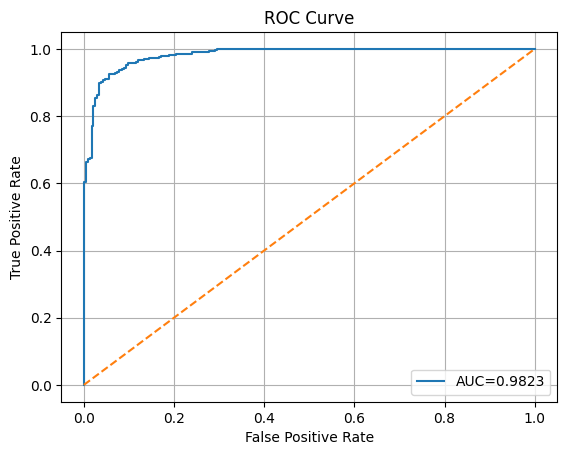

In [ ]:
fpr, tpr, _ = tf.keras.metrics.AUC(curve="ROC"), None, None  # dummy line safe to ignore

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

ROC curve interpretation:    
The ROC curve has AUC = 0.9812. AUC close to 1 means the model separates the two classes (pneumonia, non-pneumonia) very well.

8.5 Pick one correct pneumonia and one false negative / false positive

In [ ]:
t = 0.5
y_pred = (test_probs >= t).astype(int)

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]

print("correct pneumonia idx:", tp_idx[:1])
print("false negative idx:", fn_idx[:1])
print("false positive idx:", fp_idx[:1])

correct pneumonia idx: [234]
false negative idx: [315]
false positive idx: [11]


8.6 Grad-CAM helpers that handle nested models like DenseNet


Using last conv layer: conv5_block16_concat
TP example idx: [234]
TN example idx: [0]
FP example idx: [11]
FN example idx: [315]


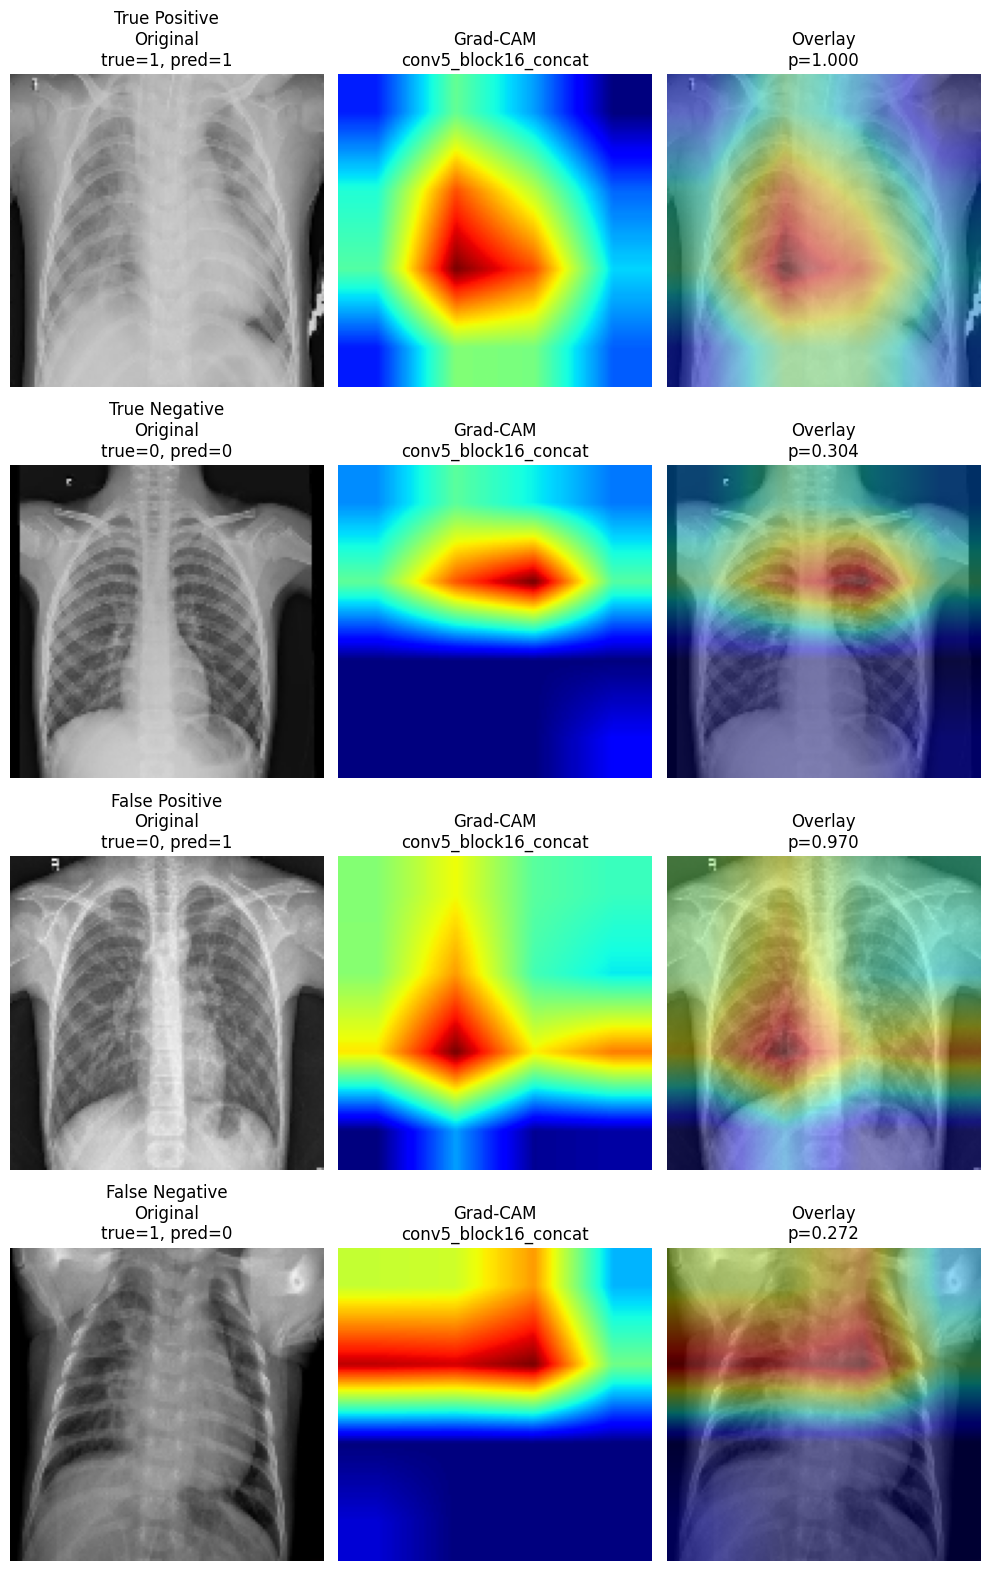

In [ ]:
# Show TP / TN / FP / FN in one single 4-row figure

base_model = chosen_model.layers[1]
gap_layer = chosen_model.get_layer("densenet_gap")
classifier_layer = chosen_model.get_layer("densenet_predictions")

# Better final DenseNet layer for Grad-CAM:
# conv5_block16_concat is the final concatenated feature map.

last_conv_layer = base_model.get_layer("conv5_block16_concat")
print("Using last conv layer:", last_conv_layer.name)

# one model that returns BOTH:
# 1) last conv activations
# 2) base model final feature map
cam_base_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

def compute_gradcam_densenet(X_model, X_display, y, probs, idx):
    img_for_model = X_model[idx]      # DenseNet-preprocessed image
    img_display = X_display[idx]      # normal [0,1] image for plotting

    pred = 1 if probs[idx] >= 0.5 else 0
    x = tf.expand_dims(img_for_model, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = cam_base_model(x, training=False)
        tape.watch(conv_outputs)

        pooled = gap_layer(base_features)
        preds = classifier_layer(pooled)

        # predicted-class Grad-CAM
        loss = preds[:, pred]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return img_display, None, pred, probs[idx]

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_display.shape[0], img_display.shape[1])
    ).numpy().squeeze()

    return img_display, heatmap_resized, pred, probs[idx]

# compute TP / TN / FP / FN indices from test set
t = 0.5
y_pred = (test_probs >= t).astype(int)

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
tn_idx = np.where((y_test == 0) & (y_pred == 0))[0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]

print("TP example idx:", tp_idx[:1])
print("TN example idx:", tn_idx[:1])
print("FP example idx:", fp_idx[:1])
print("FN example idx:", fn_idx[:1])

cases = [
    ("True Positive", tp_idx),
    ("True Negative", tn_idx),
    ("False Positive", fp_idx),
    ("False Negative", fn_idx),
]

plt.figure(figsize=(10, 16))

for row, (case_name, idx_array) in enumerate(cases):
    if len(idx_array) == 0:
        for col in range(3):
            ax = plt.subplot(4, 3, row * 3 + col + 1)
            ax.axis("off")
            if col == 1:
                ax.text(0.5, 0.5, f"No {case_name} example", ha="center", va="center", fontsize=12)
        continue

    idx = idx_array[0]
    img, heatmap_resized, pred, prob = compute_gradcam_densenet(
        X_test_for_model,
        X_test_display,
        y_test,
        test_probs,
        idx
    )

    # Original
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title(f"{case_name}\nOriginal\ntrue={y_test[idx]}, pred={pred}")
    ax1.axis("off")

    # Grad-CAM
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    if heatmap_resized is not None:
        ax2.imshow(heatmap_resized, cmap="jet")
        ax2.set_title(f"Grad-CAM\n{last_conv_layer.name}")
    else:
        ax2.text(0.5, 0.5, "Gradients are None", ha="center", va="center")
    ax2.axis("off")

    # Overlay
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    ax3.imshow(img, cmap="gray")
    if heatmap_resized is not None:
        ax3.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    ax3.set_title(f"Overlay\np={float(prob):.3f}")
    ax3.axis("off")

plt.tight_layout()
plt.show()

##Case-by-case analysis

**1. True Positive (true=1, pred=1, p=1.000)**

**What is good**

* The model correctly predicts pneumonia with very high confidence.
* The overlay focuses on the **central/lower thoracic region**, which at least overlaps with the chest area.

**What is not ideal**

* The highlighted region is **very broad and symmetric**.
* It does not clearly isolate a specific abnormal lung opacity.
* The attention looks more like a **large central blob** than a medically precise localization.

**Interpretation**

This suggests the model found enough pneumonia-related signal to classify correctly, but the explanation is **coarse rather than sharply lesion-focused**.

---

**2. True Negative (true=0, pred=0, p=0.106)**

**What is good**

* The model correctly predicts normal.
* Low pneumonia probability is appropriate.

**What is not ideal**

* The heatmap still activates strongly over the **middle/lower chest**.
* Ideally, for a normal image, we would like less suspicious localized activation, or at least clearer evidence that the model is using normal lung structure rather than a vague hot region.

**Interpretation**

Even on a correct negative case, the Grad-CAM is still broad. This suggests the model may be relying on **general chest-region patterns** rather than very specific pathology cues.

---

**3. False Positive (true=0, pred=1, p=0.576)**

**What is happening**

* The model incorrectly predicts pneumonia on a normal image.
* The heatmap focuses mostly on the **lower chest / diaphragm area**, especially one side.

**Interpretation**

It suggests the model may sometimes mistake non-pathology structures or normal appearance in the lower lung/diaphragm region as pneumonia-related evidence.
---


**4. False Negative (true=1, pred=0, p=0.499)**

**What is happening**

* The image is actually pneumonia, but the model predicts negative.
* Probability is **0.499**, so this is extremely close to the threshold.
* The heatmap highlights mainly the **upper/right side of the image**, rather than clearly the suspected pneumonia region.

**Interpretation**

This suggests the model may have **attended to the wrong area** or failed to capture the most informative pneumonia features.
Since the score is so close to 0.5, this also shows how a borderline case can flip into a false negative at the chosen threshold.


**Main takeaway**

These Grad-CAMs show that the 128x128 DenseNet has **reasonable classification performance**, but its visual explanations are **not highly localized**. The model often highlights large, diffuse chest regions instead of clearly identifying compact pathological areas. This is especially visible in the true positive and true negative examples, where the attention remains broad, and in the false positive/false negative examples, where the model appears to attend to less relevant regions.


Using last conv layer: conv5_block16_concat
TP example idx: [234]
TN example idx: [0]
FP example idx: [11]
FN example idx: [315]


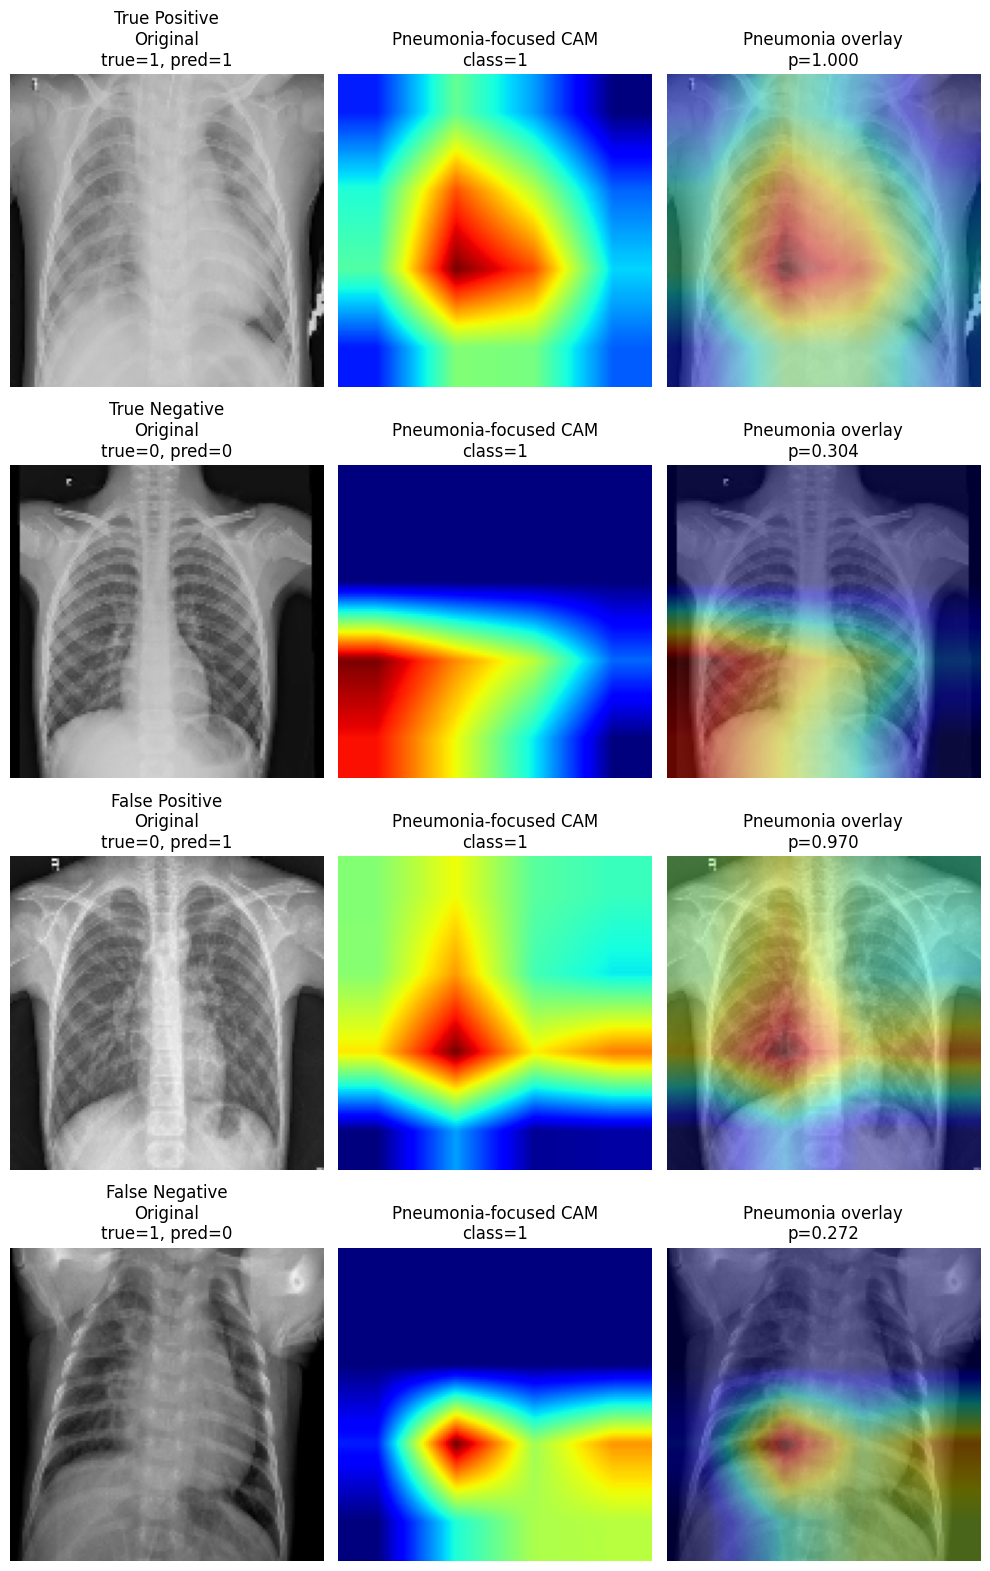

In [ ]:
# Additional cell: pneumonia-focused Grad-CAM
# This shows TP / TN / FP / FN, but always computes Grad-CAM for class 1 (pneumonia)

base_model = chosen_model.layers[1]
gap_layer = chosen_model.get_layer("densenet_gap")
classifier_layer = chosen_model.get_layer("densenet_predictions")

# Better final DenseNet layer for Grad-CAM
last_conv_layer = base_model.get_layer("conv5_block16_concat")
print("Using last conv layer:", last_conv_layer.name)

# one model that returns BOTH:
# 1) last conv activations
# 2) base model final feature map
cam_base_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

def compute_pneumonia_gradcam(X_model, X_display, y, probs, idx):
    img_for_model = X_model[idx]      # DenseNet-preprocessed image
    img_display = X_display[idx]      # normal [0,1] image for plotting

    pred = 1 if probs[idx] >= 0.5 else 0
    x = tf.expand_dims(img_for_model, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = cam_base_model(x, training=False)
        tape.watch(conv_outputs)

        pooled = gap_layer(base_features)
        preds = classifier_layer(pooled)

        # pneumonia-focused: class 1
        loss = preds[:, 1]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return img_display, None, pred, float(probs[idx])

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_display.shape[0], img_display.shape[1])
    ).numpy().squeeze()

    return img_display, heatmap_resized, pred, float(probs[idx])

# compute TP / TN / FP / FN indices from test set
t = 0.5
y_pred = (test_probs >= t).astype(int)

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0]
tn_idx = np.where((y_test == 0) & (y_pred == 0))[0]
fp_idx = np.where((y_test == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]

print("TP example idx:", tp_idx[:1])
print("TN example idx:", tn_idx[:1])
print("FP example idx:", fp_idx[:1])
print("FN example idx:", fn_idx[:1])

cases = [
    ("True Positive", tp_idx),
    ("True Negative", tn_idx),
    ("False Positive", fp_idx),
    ("False Negative", fn_idx),
]

plt.figure(figsize=(10, 16))

for row, (case_name, idx_array) in enumerate(cases):
    if len(idx_array) == 0:
        for col in range(3):
            ax = plt.subplot(4, 3, row * 3 + col + 1)
            ax.axis("off")
            if col == 1:
                ax.text(0.5, 0.5, f"No {case_name} example", ha="center", va="center", fontsize=12)
        continue

    idx = idx_array[0]
    img, heatmap_resized, pred, prob = compute_pneumonia_gradcam(
        X_test_for_model,
        X_test_display,
        y_test,
        test_probs,
        idx
    )

    # Original
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title(f"{case_name}\nOriginal\ntrue={y_test[idx]}, pred={pred}")
    ax1.axis("off")

    # Pneumonia-focused Grad-CAM
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    if heatmap_resized is not None:
        ax2.imshow(heatmap_resized, cmap="jet")
        ax2.set_title("Pneumonia-focused CAM\nclass=1")
    else:
        ax2.text(0.5, 0.5, "Gradients are None", ha="center", va="center")
    ax2.axis("off")

    # Overlay
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    ax3.imshow(img, cmap="gray")
    if heatmap_resized is not None:
        ax3.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    ax3.set_title(f"Pneumonia overlay\np={prob:.3f}")
    ax3.axis("off")

plt.tight_layout()
plt.show()

# Why this is better than the earlier predicted Grad-CAM

The earlier predicted Grad-CAM had a weakness:

* for a **true negative**, it still showed a large activated region in the chest, which made interpretation less clear.

This pneumonia-focused version is better because:

* **True negative:** almost no activation → clearer
* **True positive:** pneumonia evidence highlighted → more meaningful
* **False positive:** shows what mistaken evidence the model used
* **False negative:** shows weak/misdirected pneumonia evidence

So if we want to present **one stronger interpretability figure** for the 128×128 model, we would prefer this **pneumonia-focused CAM** over the generic predicted-class CAM.


In [ ]:
# Extra experiment: 224x224 DenseNet for better Grad-CAM resolution
# This is used for interpretability comparison, not the main classification comparison.

IMG_HEIGHT_224 = 224
IMG_WIDTH_224 = 224

def preprocess_image_densenet_224(example):
    image = example['image']
    image = tf.image.resize(image, (IMG_HEIGHT_224, IMG_WIDTH_224))
    image = tf.cast(image, tf.float32)
    image = densenet_preprocess_input(image)
    return image

def preprocess_data_densenet_224(example):
    image = preprocess_image_densenet_224(example)
    label = preprocess_label(example)
    return image, label

train_dataset_densenet_224 = data['train'].to_tf_dataset(
    columns=['image', 'label'],
    batch_size=BATCH_SIZE,
    shuffle=True
).map(preprocess_data_densenet_224)

val_dataset_densenet_224 = data['validation'].to_tf_dataset(
    columns=['image', 'label'],
    batch_size=BATCH_SIZE,
    shuffle=False
).map(preprocess_data_densenet_224)

test_dataset_densenet_224 = data['test'].to_tf_dataset(
    columns=['image', 'label'],
    batch_size=BATCH_SIZE,
    shuffle=False
).map(preprocess_data_densenet_224)

print("Sample batch from 224x224 DenseNet training dataset:")
for images, labels in train_dataset_densenet_224.take(1):
    print(f"224 DenseNet image batch shape: {images.shape}")
    print(f"224 DenseNet label batch shape: {labels.shape}")

Sample batch from 224x224 DenseNet training dataset:
224 DenseNet image batch shape: (32, 224, 224, 3)
224 DenseNet label batch shape: (32, 2)


In [ ]:
# Build and train a separate 224x224 DenseNet121 model for Grad-CAM comparison

input_shape_224 = (IMG_HEIGHT_224, IMG_WIDTH_224, 3)

densenet121_model_224 = build_densenet121_model(input_shape_224, NUM_CLASSES)
densenet121_model_224.summary()

densenet121_model_224.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

EPOCHS_224 = 5

history_densenet121_224 = densenet121_model_224.fit(
    train_dataset_densenet_224,
    epochs=EPOCHS_224,
    validation_data=val_dataset_densenet_224
)

print("224x224 DenseNet121 model training complete.")

Model: "densenet121_pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_gap                    │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet_predictions (Dense)    │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 155s 946ms/step - accuracy: 0.8868 - auc: 0.9553 - loss: 0.2807 - precision: 0.8868 - recall: 0.8868 - val_accuracy: 0.9445 - val_auc: 0.9889 - val_loss: 0.1493 - val_precision: 0.9445 - val_recall: 0.9445
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 675ms/step - accuracy: 0.9515 - auc: 0.9903 - loss: 0.1356 - precision: 0.9515 - recall: 0.9515 - val_accuracy: 0.9598 - val_auc: 0.9934 - val_loss: 0.1137 - val_precision: 0.9598 - val_recall: 0.9598
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 144s 689ms/step - accuracy: 0.9601 - auc: 0.9931 - loss: 0.1113 - precision: 0.9601 - recall: 0.9601 - val_accuracy: 0.9627 - val_auc: 0.9947 - val_loss: 0.1004 - val_precision: 0.9627 - val_recall: 0.9627
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 669ms/step - accuracy: 0.9658 - auc: 0.9948 - loss: 0.0982 - precision: 0.9658 - recall: 0.9658 - val_accuracy: 0.9722 - val_auc: 0.9963 - val_loss: 0.0855 - val_precision: 0.9722 - val_recall: 0.9722
Epoch 5/5
131/131 ━━━━

In [ ]:
# Evaluate 224x224 DenseNet separately
# This model is mainly for Grad-CAM interpretation comparison.

print("\n--- Evaluating DenseNet121 Model 224x224 ---")
results_224 = densenet121_model_224.evaluate(test_dataset_densenet_224, return_dict=True)

for metric_name, value in results_224.items():
    print(f"{metric_name}: {value:.4f}")


--- Evaluating DenseNet121 Model 224x224 ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8878 - auc: 0.9590 - loss: 0.2707 - precision: 0.8878 - recall: 0.8878
accuracy: 0.8878
auc: 0.9590
loss: 0.2707
precision: 0.8878
recall: 0.8878


This 224x224 DenseNet result is good, but numerically it is weaker than our 128x128 10-epoch DenseNet.

In [ ]:
def hf_to_numpy_display_224(split):
    # For displaying 224x224 images
    X, y = [], []
    for ex in split:
        img = tf.image.resize(ex["image"], (IMG_HEIGHT_224, IMG_WIDTH_224))
        img = tf.cast(img, tf.float32) / 255.0
        X.append(img.numpy())
        y.append(int(ex["label"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

def hf_to_numpy_densenet_224(split):
    # For 224x224 DenseNet prediction and Grad-CAM
    X, y = [], []
    for ex in split:
        img = tf.image.resize(ex["image"], (IMG_HEIGHT_224, IMG_WIDTH_224))
        img = tf.cast(img, tf.float32)
        img = densenet_preprocess_input(img)
        X.append(img.numpy())
        y.append(int(ex["label"]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_test_display_224, y_test_224 = hf_to_numpy_display_224(data["test"])
X_test_densenet_224, _ = hf_to_numpy_densenet_224(data["test"])

test_probs_224 = get_probs(densenet121_model_224, X_test_densenet_224)

print("224 display test shape:", X_test_display_224.shape)
print("224 DenseNet test shape:", X_test_densenet_224.shape)

for t in [0.3, 0.5, 0.7]:
    print(metrics_at_threshold(y_test_224, test_probs_224, t))

224 display test shape: (624, 224, 224, 3)
224 DenseNet test shape: (624, 224, 224, 3)
{'threshold': 0.3, 'recall': 0.9974358974358974, 'precision': 0.790650406504065, 'specificity': 0.5598290598290598, 'fnr': 0.002564102564102564, 'auc': 0.9848235809774271}
{'threshold': 0.5, 'recall': 0.9923076923076923, 'precision': 0.8524229074889867, 'specificity': 0.7136752136752137, 'fnr': 0.007692307692307693, 'auc': 0.9848235809774271}
{'threshold': 0.7, 'recall': 0.9769230769230769, 'precision': 0.8964705882352941, 'specificity': 0.811965811965812, 'fnr': 0.023076923076923078, 'auc': 0.9848235809774271}


The 224x224 model is more recall-oriented. It catches more pneumonia cases and has a lower false negative rate at every threshold. This is valuable in medical screening because missing pneumonia is dangerous.

The 128x128 model is more balanced. It has better precision and specificity at every threshold, meaning it creates fewer false positives.

Using last conv layer: conv5_block16_concat
224 TP example idx: [234]
224 TN example idx: [0]
224 FP example idx: [6]
224 FN example idx: [276]


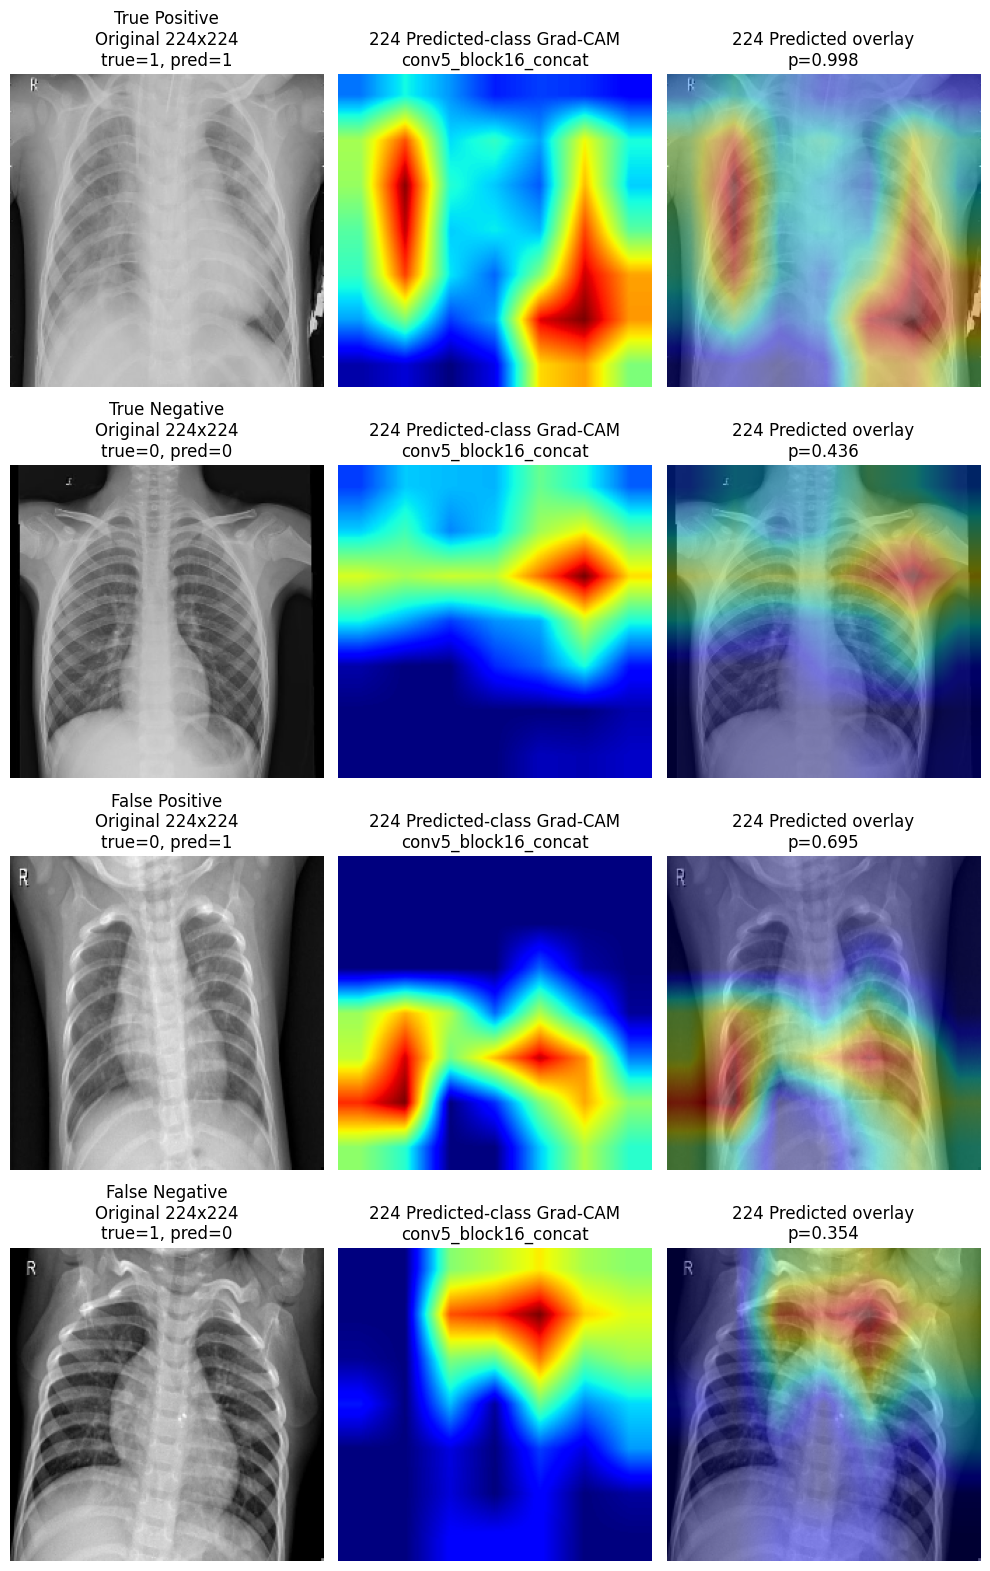

In [ ]:
# Extra cell: 224x224 predicted-class Grad-CAM
# This shows TP / TN / FP / FN, and computes Grad-CAM for the model's predicted class.

base_model_224 = densenet121_model_224.layers[1]
gap_layer_224 = densenet121_model_224.get_layer("densenet_gap")
classifier_layer_224 = densenet121_model_224.get_layer("densenet_predictions")

# Use the final DenseNet convolutional feature map.
# With 224x224 input, this gives a 7x7 feature map instead of 4x4.
last_conv_layer_224 = base_model_224.get_layer("conv5_block16_concat")
print("Using last conv layer:", last_conv_layer_224.name)

cam_base_model_224 = tf.keras.Model(
    inputs=base_model_224.input,
    outputs=[last_conv_layer_224.output, base_model_224.output]
)

def compute_predicted_gradcam_224(X_model, X_display, y, probs, idx):
    img_for_model = X_model[idx]      # 224 DenseNet-preprocessed image
    img_display = X_display[idx]      # normal 224 [0,1] image for plotting

    pred = 1 if probs[idx] >= 0.5 else 0
    x = tf.expand_dims(img_for_model, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = cam_base_model_224(x, training=False)
        tape.watch(conv_outputs)

        pooled = gap_layer_224(base_features)
        preds = classifier_layer_224(pooled)

        # predicted-class Grad-CAM
        loss = preds[:, pred]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return img_display, None, pred, float(probs[idx])

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_display.shape[0], img_display.shape[1])
    ).numpy().squeeze()

    return img_display, heatmap_resized, pred, float(probs[idx])

# compute TP / TN / FP / FN indices from 224x224 DenseNet test predictions
t = 0.5
y_pred_224 = (test_probs_224 >= t).astype(int)

tp_idx_224 = np.where((y_test_224 == 1) & (y_pred_224 == 1))[0]
tn_idx_224 = np.where((y_test_224 == 0) & (y_pred_224 == 0))[0]
fp_idx_224 = np.where((y_test_224 == 0) & (y_pred_224 == 1))[0]
fn_idx_224 = np.where((y_test_224 == 1) & (y_pred_224 == 0))[0]

print("224 TP example idx:", tp_idx_224[:1])
print("224 TN example idx:", tn_idx_224[:1])
print("224 FP example idx:", fp_idx_224[:1])
print("224 FN example idx:", fn_idx_224[:1])

cases_224 = [
    ("True Positive", tp_idx_224),
    ("True Negative", tn_idx_224),
    ("False Positive", fp_idx_224),
    ("False Negative", fn_idx_224),
]

plt.figure(figsize=(10, 16))

for row, (case_name, idx_array) in enumerate(cases_224):
    if len(idx_array) == 0:
        for col in range(3):
            ax = plt.subplot(4, 3, row * 3 + col + 1)
            ax.axis("off")
            if col == 1:
                ax.text(
                    0.5,
                    0.5,
                    f"No {case_name} example",
                    ha="center",
                    va="center",
                    fontsize=12
                )
        continue

    idx = idx_array[0]
    img, heatmap_resized, pred, prob = compute_predicted_gradcam_224(
        X_test_densenet_224,
        X_test_display_224,
        y_test_224,
        test_probs_224,
        idx
    )

    # Original
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title(f"{case_name}\nOriginal 224x224\ntrue={y_test_224[idx]}, pred={pred}")
    ax1.axis("off")

    # Predicted-class Grad-CAM
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    if heatmap_resized is not None:
        ax2.imshow(heatmap_resized, cmap="jet")
        ax2.set_title(f"224 Predicted-class Grad-CAM\n{last_conv_layer_224.name}")
    else:
        ax2.text(0.5, 0.5, "Gradients are None", ha="center", va="center")
    ax2.axis("off")

    # Overlay
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    ax3.imshow(img, cmap="gray")
    if heatmap_resized is not None:
        ax3.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    ax3.set_title(f"224 Predicted overlay\np={prob:.3f}")
    ax3.axis("off")

plt.tight_layout()
plt.show()

The 224x224 DenseNet Grad-CAM appears less uniformly blob-like than the 128x128 Grad-CAM. The highlighted regions are more shaped and more localized, which means the higher-resolution input may preserve more spatial information.

However, some activations still appear outside the most clinically meaningful lung regions, especially near the image edge, shoulder/side region, or upper chest. So the 224x224 model may improve visual detail, but the explanations are still imperfect.

Using last conv layer: conv5_block16_concat
224 TP example idx: [234]
224 TN example idx: [0]
224 FP example idx: [6]
224 FN example idx: [276]


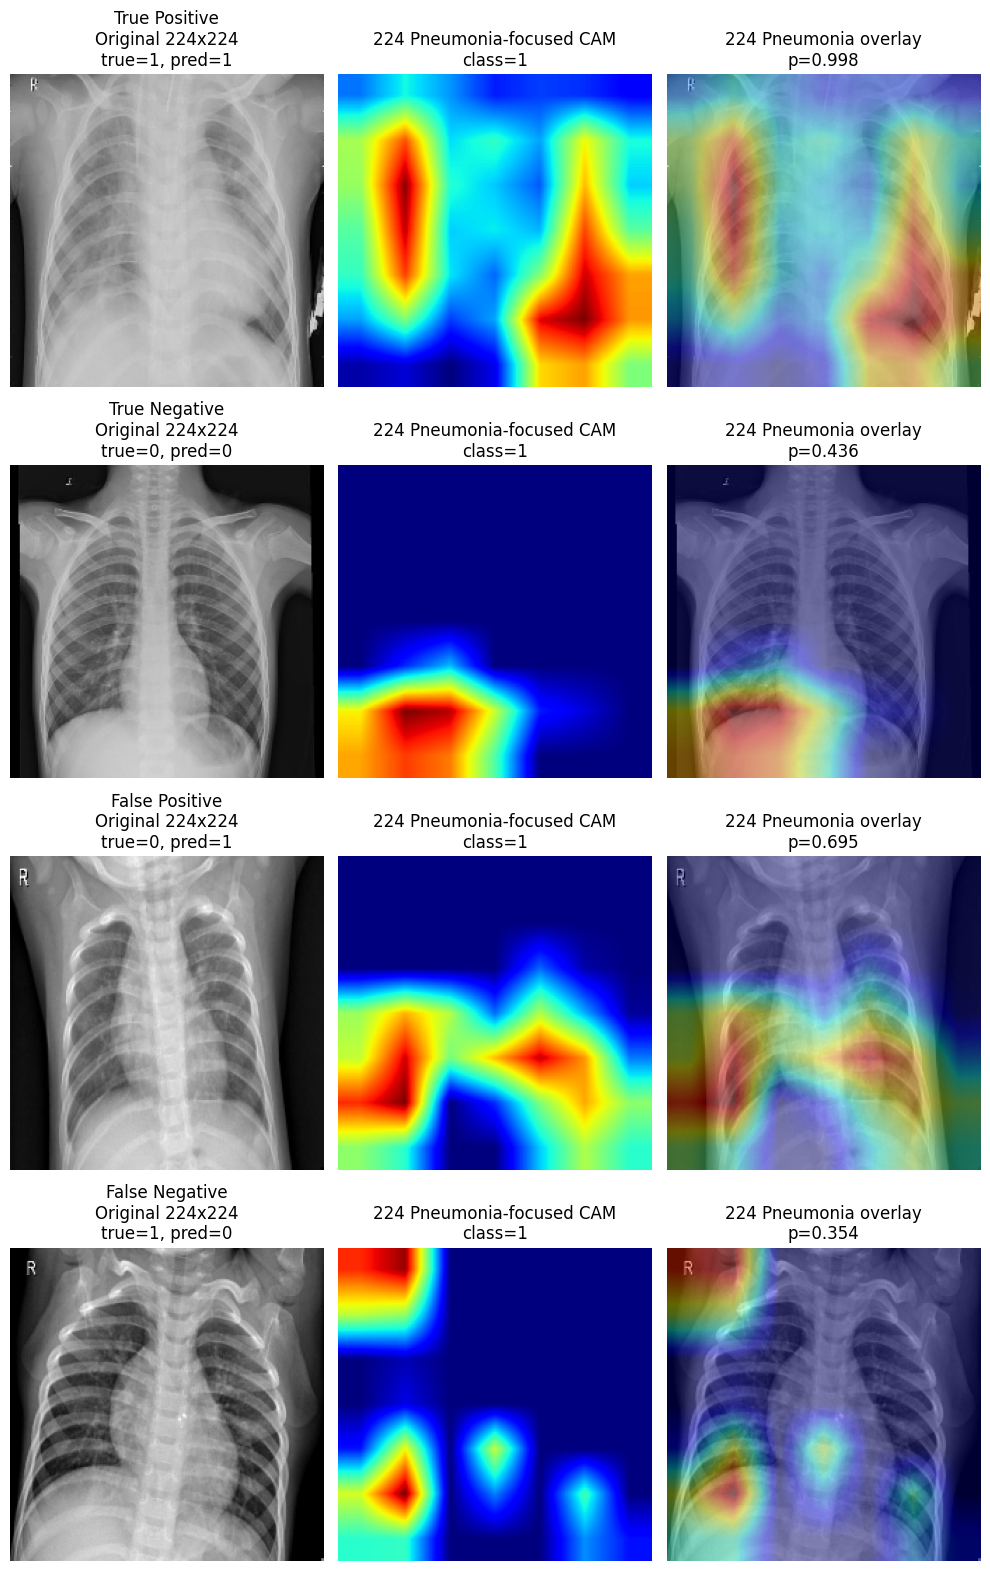

In [ ]:
# Extra cell: 224x224 pneumonia-focused Grad-CAM
# This is used to compare interpretability with the 128x128 DenseNet Grad-CAM.

base_model_224 = densenet121_model_224.layers[1]
gap_layer_224 = densenet121_model_224.get_layer("densenet_gap")
classifier_layer_224 = densenet121_model_224.get_layer("densenet_predictions")

# With 224x224 input, this layer has a 7x7 final feature map instead of 4x4.
last_conv_layer_224 = base_model_224.get_layer("conv5_block16_concat")
print("Using last conv layer:", last_conv_layer_224.name)

cam_base_model_224 = tf.keras.Model(
    inputs=base_model_224.input,
    outputs=[last_conv_layer_224.output, base_model_224.output]
)

def compute_pneumonia_gradcam_224(X_model, X_display, y, probs, idx):
    img_for_model = X_model[idx]      # 224 DenseNet-preprocessed image
    img_display = X_display[idx]      # normal 224 [0,1] image for plotting

    pred = 1 if probs[idx] >= 0.5 else 0
    x = tf.expand_dims(img_for_model, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = cam_base_model_224(x, training=False)
        tape.watch(conv_outputs)

        pooled = gap_layer_224(base_features)
        preds = classifier_layer_224(pooled)

        # pneumonia-focused: class 1
        loss = preds[:, 1]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return img_display, None, pred, float(probs[idx])

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_display.shape[0], img_display.shape[1])
    ).numpy().squeeze()

    return img_display, heatmap_resized, pred, float(probs[idx])

# compute TP / TN / FP / FN indices from 224x224 DenseNet test predictions
t = 0.5
y_pred_224 = (test_probs_224 >= t).astype(int)

tp_idx_224 = np.where((y_test_224 == 1) & (y_pred_224 == 1))[0]
tn_idx_224 = np.where((y_test_224 == 0) & (y_pred_224 == 0))[0]
fp_idx_224 = np.where((y_test_224 == 0) & (y_pred_224 == 1))[0]
fn_idx_224 = np.where((y_test_224 == 1) & (y_pred_224 == 0))[0]

print("224 TP example idx:", tp_idx_224[:1])
print("224 TN example idx:", tn_idx_224[:1])
print("224 FP example idx:", fp_idx_224[:1])
print("224 FN example idx:", fn_idx_224[:1])

cases_224 = [
    ("True Positive", tp_idx_224),
    ("True Negative", tn_idx_224),
    ("False Positive", fp_idx_224),
    ("False Negative", fn_idx_224),
]

plt.figure(figsize=(10, 16))

for row, (case_name, idx_array) in enumerate(cases_224):
    if len(idx_array) == 0:
        for col in range(3):
            ax = plt.subplot(4, 3, row * 3 + col + 1)
            ax.axis("off")
            if col == 1:
                ax.text(0.5, 0.5, f"No {case_name} example", ha="center", va="center", fontsize=12)
        continue

    idx = idx_array[0]
    img, heatmap_resized, pred, prob = compute_pneumonia_gradcam_224(
        X_test_densenet_224,
        X_test_display_224,
        y_test_224,
        test_probs_224,
        idx
    )

    # Original
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title(f"{case_name}\nOriginal 224x224\ntrue={y_test_224[idx]}, pred={pred}")
    ax1.axis("off")

    # Pneumonia-focused Grad-CAM
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    if heatmap_resized is not None:
        ax2.imshow(heatmap_resized, cmap="jet")
        ax2.set_title("224 Pneumonia-focused CAM\nclass=1")
    else:
        ax2.text(0.5, 0.5, "Gradients are None", ha="center", va="center")
    ax2.axis("off")

    # Overlay
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    ax3.imshow(img, cmap="gray")
    if heatmap_resized is not None:
        ax3.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    ax3.set_title(f"224 Pneumonia overlay\np={prob:.3f}")
    ax3.axis("off")

plt.tight_layout()
plt.show()

Compared with the 128x128 pneumonia-focused Grad-CAM, the 224x224 version looks more localized and less uniformly blob-like. The highlighted areas are more specific, so the visualization is easier to discuss case by case.

However, it is not perfectly clinically localized. Some activations appear near the lower edge, side edge, or upper corner of the image, so we should not claim that the model precisely identifies pneumonia lesions.

#9. Summary  

Grad-CAM was used to improve interpretability.
The 224x224 DenseNet121 pneumonia-focused Grad-CAM visualizations provide a more detailed view of the model's pneumonia-related attention than the 128x128 model. In the true positive example, the model correctly predicts pneumonia with high confidence and produces a more localized activation pattern, suggesting that higher-resolution input may preserve more spatial information for interpretation. In the true negative example, the model predicts normal but remains close to the decision threshold, and the CAM shows only limited activation, indicating weak pneumonia-like evidence. In the false positive case, the model incorrectly highlights a lower lateral region, suggesting that nonspecific anatomical or image-edgefeatures may contribute to false alarms. In the false negative case, the model fails to strongly activate over the relevant lung region, which may explain the missed pneumonia prediction. Overall, the 224x224 model improves Grad-CAM spatial detail compared with the 128x128 model, but the heatmaps remain imperfect and should be interpreted as model attention rather than exact medical localization.

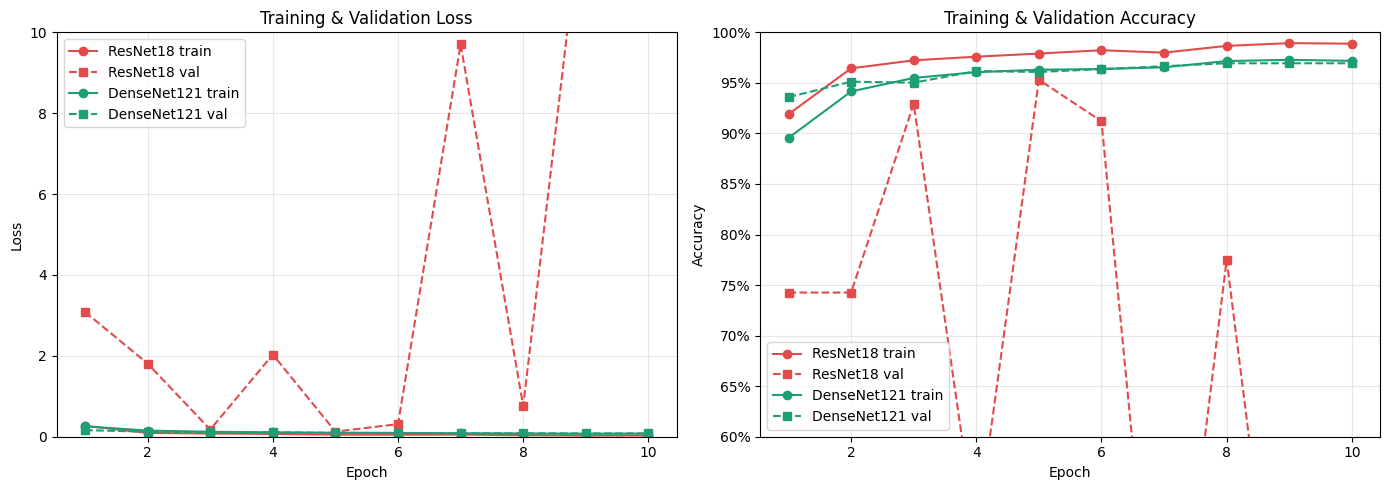

In [ ]:
import matplotlib.pyplot as plt

r18 = {
    'loss':         [0.2678, 0.0941, 0.0784, 0.0691, 0.0517, 0.0493, 0.0534, 0.0363, 0.0282, 0.0291],
    'accuracy':     [0.9190, 0.9644, 0.9723, 0.9759, 0.9790, 0.9823, 0.9799, 0.9866, 0.9893, 0.9888],
    'val_loss':     [3.0842, 1.8085, 0.1768, 2.0311, 0.1266, 0.3122, 9.7048,0.7568, 13.9171, 25.1730],
    'val_accuracy': [0.7426, 0.7426, 0.9292, 0.5014, 0.9531, 0.9120, 0.2699, 0.7751, 0.2833, 0.2641],
}

dn = {
    'loss':         [0.2571, 0.1513, 0.1221, 0.1075, 0.0982, 0.0946, 0.0846, 0.0787, 0.0743, 0.0767],
    'accuracy':     [0.8956, 0.9415, 0.9549, 0.9606, 0.9630, 0.9637, 0.9654, 0.9716, 0.9728, 0.9718],
    'val_loss':     [0.1627, 0.1234, 0.1090, 0.1084, 0.0950, 0.0922, 0.0851, 0.0844, 0.0818, 0.0823],
    'val_accuracy': [0.9359, 0.9512, 0.9502, 0.9617, 0.9608, 0.9636, 0.9665, 0.9694, 0.9694, 0.9694],
}

r18_epochs = range(1, len(r18['loss']) + 1)
dn_epochs  = range(1, len(dn['loss']) + 1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(r18_epochs, r18['loss'],     'o-',  color='#E24B4A', label='ResNet18 train')
ax1.plot(r18_epochs, r18['val_loss'], 's--', color='#E24B4A', label='ResNet18 val')
ax1.plot(dn_epochs,  dn['loss'],      'o-',  color='#1D9E75', label='DenseNet121 train')
ax1.plot(dn_epochs,  dn['val_loss'],  's--', color='#1D9E75', label='DenseNet121 val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.set_ylim(0, 10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(r18_epochs, r18['accuracy'],     'o-',  color='#E24B4A', label='ResNet18 train')
ax2.plot(r18_epochs, r18['val_accuracy'], 's--', color='#E24B4A', label='ResNet18 val')
ax2.plot(dn_epochs,  dn['accuracy'],      'o-',  color='#1D9E75', label='DenseNet121 train')
ax2.plot(dn_epochs,  dn['val_accuracy'],  's--', color='#1D9E75', label='DenseNet121 val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.set_ylim(0.6, 1.0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ResNet18 shows significant overfitting on our dataset. Training loss drops smoothly to near zero, but then the validation loss starts to fluctuate wildly from 6th epoch onwards — the model memorizes training data but fails to generalize.

DenseNet121, which actually has fewer training parameters tells the opposite story. Train and validation curves converge tightly, with validation accuracy steadily climbing to ~97% and val loss settling below 0.1.

ResNet18 has wider, more independent layers, and therefore, lots of spare capacity. Therefore, on our dataset (which is not too big) it memorizes instead of generalizing.

DenseNet121 forces every layer to reuse all previous features and only add a narrow sliver of new ones. To begin with, it alreday has a far narrower structure, so each new layer's nodes don't carry training memory from previous layer nodes. This leads to far less redundancy, fewer parameters, and most importantly, built-in regularization. This is why we see that the training and validation curves converge.




In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Re-import DenseNet preprocessing (if not globally available due to execution order)
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess_input

# Re-define IMG_HEIGHT, IMG_WIDTH for clarity and robustness, consistent with the trained DenseNet model
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CLASSES = 2 # 0 for normal, 1 for pneumonia

# Ensure the model and its components are available for Grad-CAM.
# This block attempts to re-use the 'densenet121_model' and its layers
# setup in previous cells. If not found (e.g., kernel restart), it attempts to rebuild
# (though the rebuilt model would be untrained without running prior training cells).
if 'densenet121_model' not in globals():
    print("Warning: 'densenet121_model' not found. Attempting to rebuild a placeholder model.")
    print("         For accurate predictions, please ensure all previous model training cells are run.")
    from tensorflow.keras import layers, models, applications

    def build_densenet121_model_placeholder(input_shape, num_classes):
        base_model = applications.DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
        base_model.trainable = False
        inputs = tf.keras.Input(shape=input_shape)
        x = base_model(inputs, training=False)
        x = layers.GlobalAveragePooling2D(name="densenet_gap")(x)
        outputs = layers.Dense(num_classes, activation='softmax', name="densenet_predictions")(x)
        model = models.Model(inputs, outputs, name='densenet121_pneumonia')
        return model

    densenet121_model = build_densenet121_model_placeholder((IMG_HEIGHT, IMG_WIDTH, 3), NUM_CLASSES)

# Assign the chosen model for prediction and Grad-CAM
chosen_model = densenet121_model

# Extract necessary layers for Grad-CAM, assuming the model structure defined earlier.
# These are specifically from the densenet121_model.
base_model = chosen_model.layers[1] # DenseNet121 base is usually the second layer after input
gap_layer = chosen_model.get_layer("densenet_gap")
classifier_layer = chosen_model.get_layer("densenet_predictions")
last_conv_layer = base_model.get_layer("conv5_block16_concat") # As identified in previous Grad-CAM cells

# Create a sub-model that outputs both the last convolutional layer activations and the base model's output
cam_base_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

def load_and_preprocess_single_image(image_bytes):
    """Loads an image from bytes, resizes, and preprocesses for DenseNet and display."""
    img = Image.open(tf.io.decode_image(image_bytes, channels=3)).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))

    # For display (normalized 0-1)
    img_display = np.array(img).astype(np.float32) / 255.0

    # For model input (DenseNet specific preprocessing)
    img_model_input = np.array(img).astype(np.float32)
    img_model_input = densenet_preprocess_input(img_model_input)
    img_model_input = np.expand_dims(img_model_input, axis=0) # Add batch dimension

    return img_display, img_model_input

def compute_pneumonia_gradcam_for_single_image(img_model_input, img_display):
    """Computes pneumonia-focused Grad-CAM for a single image."""
    x = img_model_input

    with tf.GradientTape() as tape:
        conv_outputs, base_features = cam_base_model(x, training=False)
        tape.watch(conv_outputs)

        pooled = gap_layer(base_features)
        preds = classifier_layer(pooled)

        # pneumonia-focused: class 1
        loss = preds[:, 1] # Compute gradients for the pneumonia class output

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        print("Gradients are None, cannot compute Grad-CAM.")
        return None

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) # Pool gradients across spatial dimensions

    conv_outputs = conv_outputs[0] # Remove batch dimension for single image
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1) # Multiply and sum activations by pooled gradients
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8) # Normalize heatmap
    heatmap = heatmap.numpy()

    # Resize heatmap to original image dimensions for overlay
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_display.shape[0], img_display.shape[1])
    ).numpy().squeeze()

    return heatmap_resized

def on_upload_change(change):
    """Callback function to process uploaded images."""
    output_area.clear_output()
    with output_area:
        if not uploader.value:
            print("No files selected.")
            return

        for filename, file_info in uploader.value.items():
            print(f"Processing {filename}...")
            content = file_info['content']

            img_display, img_model_input = load_and_preprocess_single_image(content)

            # Make prediction
            predictions = chosen_model.predict(img_model_input, verbose=0)
            pneumonia_prob = predictions[0, 1] # Probability of class 1 (pneumonia)
            predicted_class = 1 if pneumonia_prob >= 0.5 else 0 # Assuming 0.5 threshold
            class_name = "Pneumonia" if predicted_class == 1 else "Normal"

            print(f"Predicted class for {filename}: {class_name} (Probability: {pneumonia_prob:.4f})")

            # Generate Grad-CAM
            heatmap = compute_pneumonia_gradcam_for_single_image(
                img_model_input, img_display
            )

            plt.figure(figsize=(12, 4))

            # Original Image
            plt.subplot(1, 3, 1)
            plt.imshow(img_display)
            plt.title(f"Original: {filename}")
            plt.axis("off")

            if heatmap is not None:
                # Heatmap
                plt.subplot(1, 3, 2)
                plt.imshow(heatmap, cmap="jet")
                plt.title("Pneumonia-focused Grad-CAM")
                plt.axis("off")

                # Overlay
                plt.subplot(1, 3, 3)
                plt.imshow(img_display)
                plt.imshow(heatmap, cmap="jet", alpha=0.4)
                plt.title(f"Overlay\nPredicted: {class_name} (p={pneumonia_prob:.3f})")
                plt.axis("off")
            else:
                plt.subplot(1, 3, 2)
                plt.text(0.5, 0.5, "Grad-CAM not available", ha="center", va="center")
                plt.axis("off")
                plt.subplot(1, 3, 3)
                plt.text(0.5, 0.5, "Overlay not available", ha="center", va="center")
                plt.axis("off")

            plt.tight_layout()
            plt.show()

# Setup file upload widget
uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png', # Accept common image formats
    multiple=True,             # Allow multiple file uploads
    description='Upload X-ray Images'
)
output_area = widgets.Output() # Output widget to display results

uploader.observe(on_upload_change, names='value') # Attach callback function to uploader

print("Upload X-ray images below to get predictions and Grad-CAM visualizations.")
display(uploader, output_area)
